# Cosine Similarity With Random Graphs

## 📦 **Package Import**

In [1]:
# python
import pandas as pd
import numpy as np
from IPython.display import display, Markdown
import sys
import os
from pathlib import Path
import re

# algorithms4pepprotgraphs framework
sys.path.append('/home/jovyan/work/algorithms4pepprotgraphs')
from algorithms4pepprotgraphs.module.notebook import NotebookApp
from algorithms4pepprotgraphs.util.plotting import boxplot, scatter

app = NotebookApp('.env.jupyter.AVPDiscover.Ext')
paths = app.paths()

[2025-04-08 17:26:12,639] WARNING [data_validator.py:87] Sequences with non-natural amino acids were excluded. See: /home/jovyan/work/output/results/AVPDiscover/Ext/Log/Sequences with Non-Natural Amino Acids.csv
[2025-04-08 17:26:29,376] INFO [notebook.py:70] Setting:
dataset_path: /home/jovyan/work/algorithms4pepprotgraphs/dataset/AVPDiscover/AVP-external.csv
pdb_path: /home/jovyan/work/algorithms4pepprotgraphs/dataset/AVPDiscover/ESMFold_pdbs
notebook_output_path: /home/jovyan/work/output/results/AVPDiscover/Ext
sequence_analysis_path: /home/jovyan/work/algorithms4pepprotgraphs/output/results/AVPDiscover/Ext/2025-04-07T19.52.26-Sequence_Analyzer
graph_analysis_path: /home/jovyan/work/algorithms4pepprotgraphs/output/results/AVPDiscover/Ext/2025-04-07T21.26.46-Graph_Analyzer
min_seq_len: 10
max_seq_len: 100


## 📊 **Data Analysis**

### **Data**

In [2]:
data = pd.read_csv(app.graph_analysis['similarity_with_random_graphs'])

data["distance_interval"] = data["distance_function"] + " " + data["interval"].astype(str)

statistics = pd.read_csv(
    app.graph_analysis['similarity_with_random_graphs_summary'].with_name(
        app.graph_analysis['similarity_with_random_graphs_summary'].name + "-cosine_similarity.csv"
    )
)

statistics["distance_interval"] = statistics["distance_function"] + " " + statistics["interval"].astype(str)

data[["sequence", "distance_interval", "cosine_similarity"]].head()

,sequence,distance_interval,cosine_similarity
0,GWFDVVKHIASAV,"euclidean (0, 10.2836)",0.668446
1,GWFDVVKHIASAV,"euclidean (0, 10.2836)",0.598816
2,GWFDVVKHIASAV,"euclidean (0, 10.2836)",0.740041
3,GWFDVVKHIASAV,"euclidean (0, 10.2836)",0.618601
4,GWFDVVKHIASAV,"euclidean (0, 10.2836)",0.526291


### **Distance Intervals**

In [3]:
unique_values = pd.Series(pd.concat([statistics["distance_interval"], statistics["distance_interval"]]).unique()).sort_values()
display(Markdown("\n".join(f"- {val}" for val in unique_values)))

- angular_separation (0, 0.018)
- angular_separation (0, 0.0654)
- angular_separation (0, 0.1799)
- bhattacharyya (0, 1.5158)
- bhattacharyya (0, 2.4304)
- bhattacharyya (0, 3.6452)
- canberra (0, 0.6155)
- canberra (0, 1.0142)
- canberra (0, 1.4712)
- clark (0, 0.4161)
- clark (0, 0.6813)
- clark (0, 0.983)
- euclidean (0, 10.2836)
- euclidean (0, 16.6132)
- euclidean (0, 26.242)
- lance_williams (0, 0.1789)
- lance_williams (0, 0.3041)
- lance_williams (0, 0.466)
- soergel (0, 0.3035)
- soergel (0, 0.4664)
- soergel (0, 0.6357)

### **Number of Random Graphs per Distance Interval**

In [4]:
first_sequence = data["sequence"].iloc[0]
df_filtered = data[data["sequence"] == first_sequence]
count = df_filtered.groupby(["distance_function", "interval"])["random_graph"].count()
display(Markdown("\n".join(f"- {idx[0]}, {idx[1]}: {val}" for idx, val in count.items())))

- angular_separation, (0, 0.018): 30
- angular_separation, (0, 0.0654): 30
- angular_separation, (0, 0.1799): 30
- bhattacharyya, (0, 1.5158): 30
- bhattacharyya, (0, 2.4304): 30
- bhattacharyya, (0, 3.6452): 30
- canberra, (0, 0.6155): 30
- canberra, (0, 1.0142): 30
- canberra, (0, 1.4712): 30
- clark, (0, 0.4161): 30
- clark, (0, 0.6813): 30
- clark, (0, 0.983): 30
- euclidean, (0, 10.2836): 30
- euclidean, (0, 16.6132): 30
- euclidean, (0, 26.242): 30
- lance_williams, (0, 0.1789): 30
- lance_williams, (0, 0.3041): 30
- lance_williams, (0, 0.466): 30
- soergel, (0, 0.3035): 30
- soergel, (0, 0.4664): 30
- soergel, (0, 0.6357): 30

### **Statistics**

In [5]:
columns = ["distance_interval", "count", "min", "mean", "std", "p25", "p50", "p75", "max", "skewness", "kurtosis"]
display(statistics.reset_index(drop=True)[columns])

,distance_interval,count,min,mean,std,p25,p50,p75,max,skewness,kurtosis
0,"angular_separation (0, 0.018)",592560,-0.966167,0.479233,0.237233,0.362303,0.513426,0.646731,0.997645,-1.242032,5.647209
1,"angular_separation (0, 0.0654)",592620,-0.910106,0.589120,0.197305,0.516895,0.632205,0.712300,0.994564,-2.249697,10.674705
2,"angular_separation (0, 0.1799)",592620,-0.777295,0.648058,0.185155,0.622482,0.690070,0.735988,0.987527,-3.627910,19.144777
3,"bhattacharyya (0, 1.5158)",592620,-0.882061,0.492217,0.171638,0.387625,0.486775,0.598688,0.996277,-0.350195,4.615568
4,"bhattacharyya (0, 2.4304)",592620,-0.832621,0.606163,0.126209,0.519922,0.603759,0.692365,0.991163,-0.015764,2.990451
5,"bhattacharyya (0, 3.6452)",592620,-0.617383,0.672718,0.099175,0.612729,0.677521,0.736756,0.976788,-1.758251,20.635942
6,"canberra (0, 0.6155)",592410,-0.946365,0.521723,0.196343,0.440367,0.539832,0.636989,0.992854,-1.950772,11.336734
7,"canberra (0, 1.0142)",592620,-0.939717,0.627416,0.121812,0.555691,0.632155,0.706398,0.992524,-1.105446,10.653239
8,"canberra (0, 1.4712)",592620,-0.655017,0.676632,0.091030,0.622111,0.680447,0.734645,0.998591,-0.998425,12.174321
9,"clark (0, 0.4161)",592440,-0.937521,0.523064,0.204357,0.446120,0.546179,0.642363,0.991958,-1.989654,10.687926


### **Analysis of Graph Similarity Distribution (*per Percentile*)**

#### **25th Percentile**

<br>*Cosine Similarity with Random Graphs (25th Percentile)*

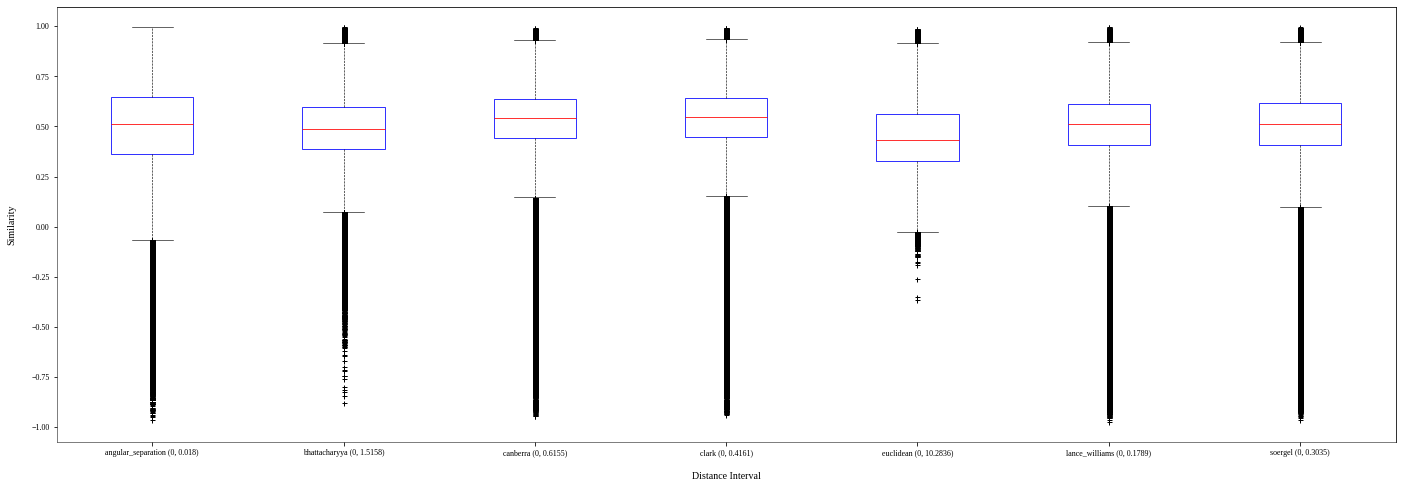

<br>*Cosine Similarity with Random Graphs (25th Percentile)*

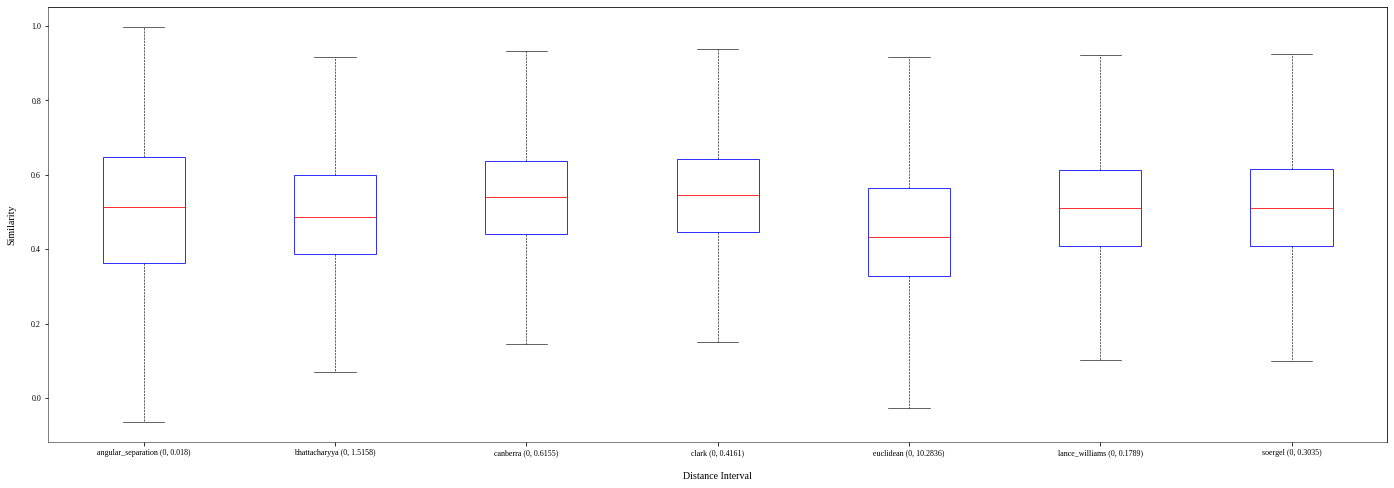

In [6]:
distance_intervals = [
    'euclidean (0, 10.2836)',
    'angular_separation (0, 0.018)',
    'bhattacharyya (0, 1.5158)',
    'canberra (0, 0.6155)',
    'clark (0, 0.4161)',
    'lance_williams (0, 0.1789)',
    'soergel (0, 0.3035)'  
]

regex_pattern = '|'.join([re.escape(interval) for interval in distance_intervals])

data_rg = data.dropna(subset=['cosine_similarity']).copy()
data_rg = data_rg[data_rg['distance_interval'].astype(str).str.contains(regex_pattern, na=False)]

x_axis = 'distance_interval'
y_axis = 'cosine_similarity'
x_label = 'Distance Interval'
y_label = 'Similarity'
fig_size=(24, 8)
x_tick_rotation=0
y_lim=None

display(Markdown("<br>*Cosine Similarity with Random Graphs (25th Percentile)*"))
output = paths['graph_similarity_path'].joinpath("Cosine Similarity with Random Graphs (p25_distance_intervals) -boxplot")
plt = boxplot(data_rg, x_axis, y_axis, x_label, y_label, y_lim=y_lim, output=output, fig_size=fig_size, x_tick_rotation=x_tick_rotation)
plt.show()

display(Markdown("<br>*Cosine Similarity with Random Graphs (25th Percentile)*"))
output = paths['graph_similarity_path'].joinpath("Cosine Similarity with Random Graphs (p25_distance_intervals) -boxplot_without_outliter")
plt = boxplot(data_rg, x_axis, y_axis, x_label, y_label, y_lim=y_lim, output=output, fig_size=fig_size, x_tick_rotation=x_tick_rotation, show_fliers=False)
plt.show()

#### **50th Percentile**

<br>*Cosine Similarity with Random Graphs (50th Percentile)*

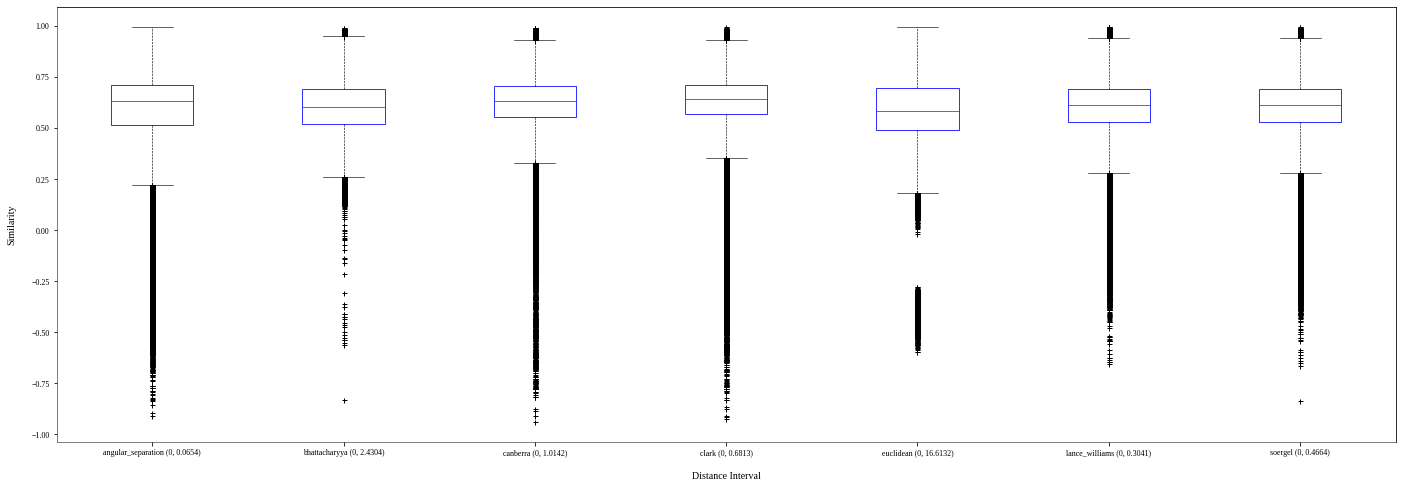

<br>*Cosine Similarity with Random Graphs (20th Percentile)*

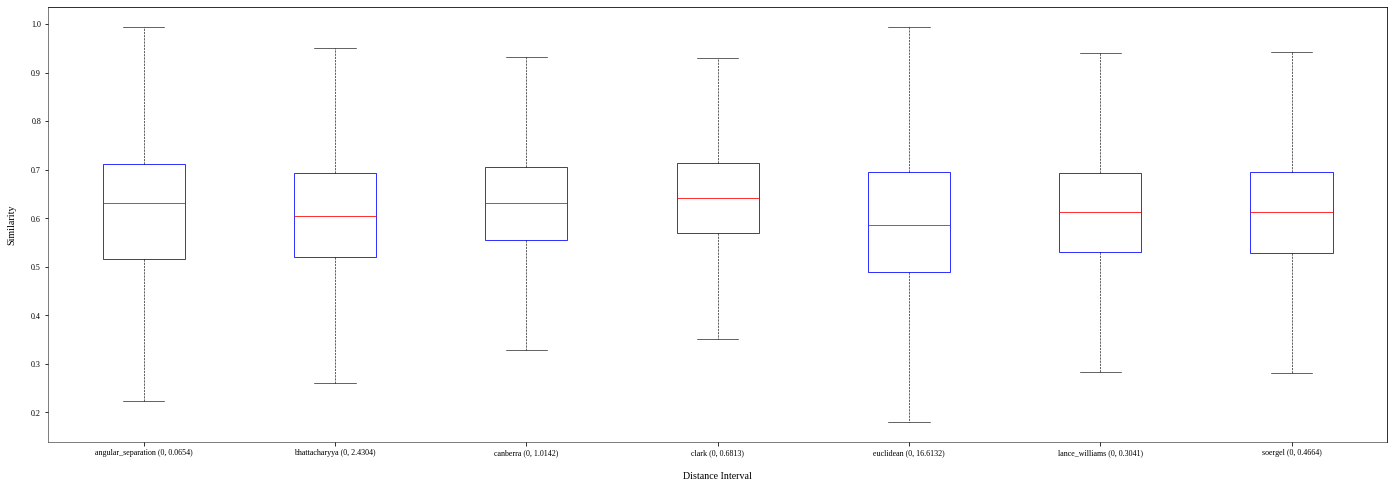

In [7]:
distance_intervals = [
    'euclidean (0, 16.6132)',
    'angular_separation (0, 0.0654)',
    'bhattacharyya (0, 2.4304)',
    'canberra (0, 1.0142)',
    'clark (0, 0.6813)',
    'lance_williams (0, 0.3041)',
    'soergel (0, 0.4664)'  
]

regex_pattern = '|'.join([re.escape(interval) for interval in distance_intervals])

data_rg = data.dropna(subset=['cosine_similarity']).copy()
data_rg = data_rg[data_rg['distance_interval'].astype(str).str.contains(regex_pattern, na=False)]

x_axis = 'distance_interval'
y_axis = 'cosine_similarity'
x_label = 'Distance Interval'
y_label = 'Similarity'
fig_size=(24, 8)
x_tick_rotation=0
y_lim=None

display(Markdown("<br>*Cosine Similarity with Random Graphs (50th Percentile)*"))
output = paths['graph_similarity_path'].joinpath("Cosine Similarity with Random Graphs (p50_distance_intervals) -boxplot_without_outliter")
plt = boxplot(data_rg, x_axis, y_axis, x_label, y_label, y_lim=y_lim, output=output, fig_size=fig_size, x_tick_rotation=x_tick_rotation)
plt.show()

display(Markdown("<br>*Cosine Similarity with Random Graphs (20th Percentile)*"))
output = paths['graph_similarity_path'].joinpath("Cosine Similarity with Random Graphs (p50_distance_intervals) -boxplot_without_outliter")
plt = boxplot(data_rg, x_axis, y_axis, x_label, y_label, y_lim=y_lim, output=output, fig_size=fig_size, x_tick_rotation=x_tick_rotation, show_fliers=False)
plt.show()

#### **75th Percentile**

<br>*Cosine Similarity with Random Graphs (75th Percentile)*

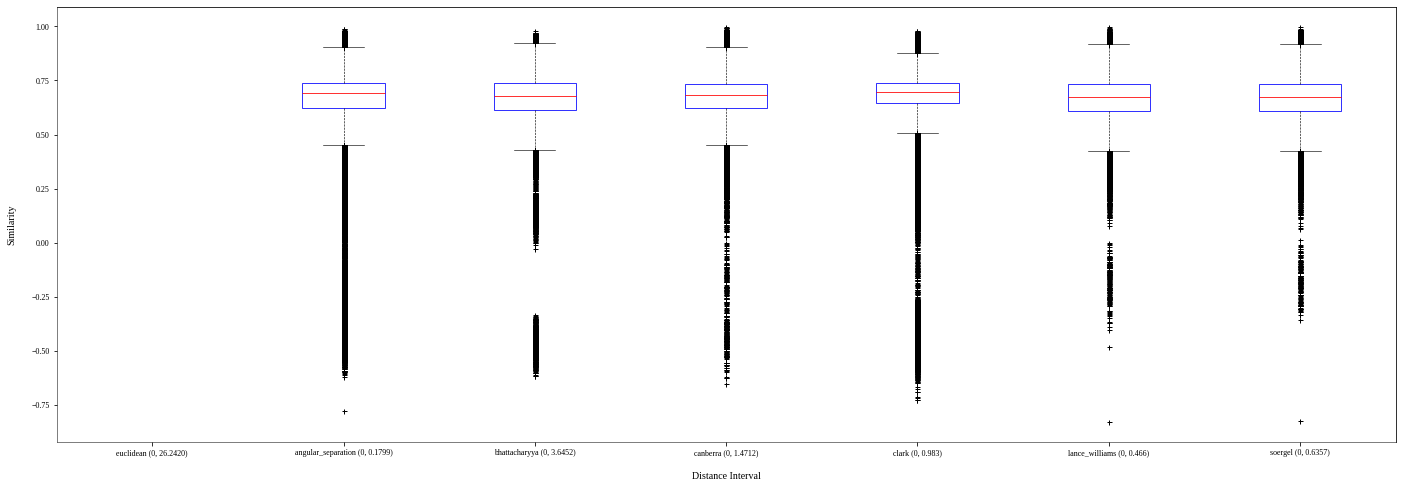

<br>*Cosine Similarity with Random Graphs (75th Percentile)*

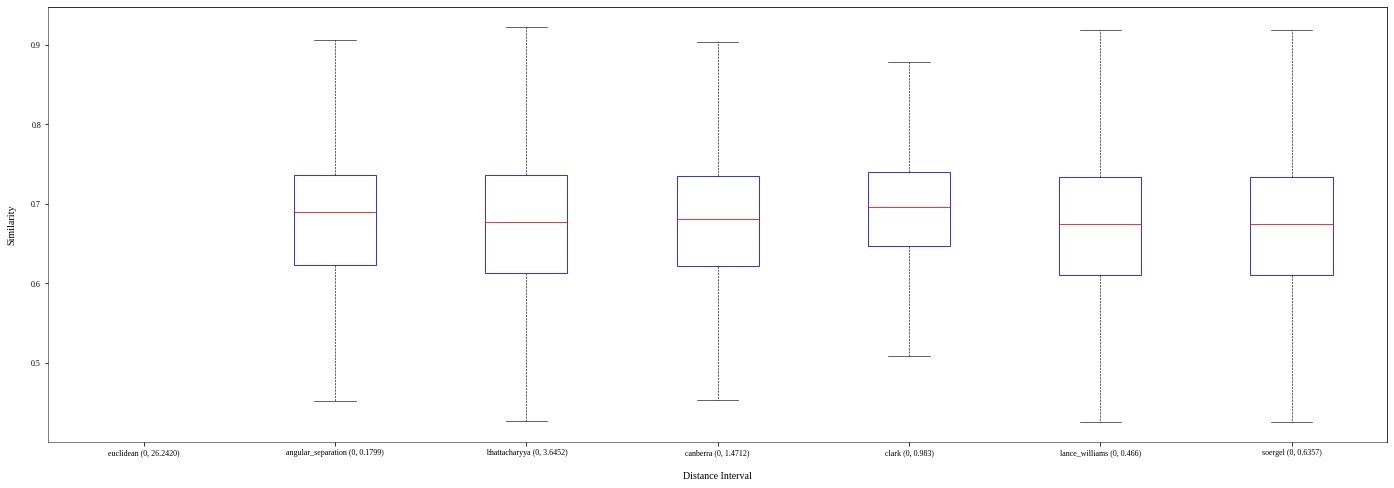

In [8]:
distance_intervals = [
    'euclidean (0, 26.2420)',
    'angular_separation (0, 0.1799)',
    'bhattacharyya (0, 3.6452)',
    'canberra (0, 1.4712)',
    'clark (0, 0.983)',
    'lance_williams (0, 0.466)',
    'soergel (0, 0.6357)'  
]

regex_pattern = '|'.join([re.escape(interval) for interval in distance_intervals])

data_rg = data.dropna(subset=['cosine_similarity']).copy()
data_rg = data_rg[data_rg['distance_interval'].astype(str).str.contains(regex_pattern, na=False)]

x_axis = 'distance_interval'
y_axis = 'cosine_similarity'
x_label = 'Distance Interval'
y_label = 'Similarity'
fig_size=(24, 8)
x_tick_rotation=0
y_lim=None

display(Markdown("<br>*Cosine Similarity with Random Graphs (75th Percentile)*"))
output = paths['graph_similarity_path'].joinpath("Cosine Similarity with Random Graphs (p75_distance_intervals) -boxplot_without_outliter")
plt = boxplot(data_rg, x_axis, y_axis, x_label, y_label, y_lim=y_lim, output=output, fig_size=fig_size, x_tick_rotation=x_tick_rotation, categories=distance_intervals)
plt.show()

display(Markdown("<br>*Cosine Similarity with Random Graphs (75th Percentile)*"))
output = paths['graph_similarity_path'].joinpath("Cosine Similarity with Random Graphs (p75_distance_intervals) -boxplot_without_outliter")
plt = boxplot(data_rg, x_axis, y_axis, x_label, y_label, y_lim=y_lim, output=output, fig_size=fig_size, x_tick_rotation=x_tick_rotation, show_fliers=False, categories=distance_intervals)
plt.show()